# Physical baseline model — data workflow and results

**What it answers:** how much more electricity a heat-pump house uses than a
code-compliant version of itself, and how much of its heating the building does
not justify. Computed from building geometry, construction era and published Swiss
standards (TABULA, SIA 380/1, SIA 384.201, FAWA / WPZ Buchs).

**The rule behind everything:** no constant is ever fitted to the meter. The
physics is computed first; the meter is only used to compare against it.

**How to read this notebook:** each section is one stage, P0 to P13, in the order
they were built. Each shows what the stage did, the number it produced, and — where
it matters — a figure. Stages P2 to P4 were superseded and appear as notes only.

```
protocols.csv ──► p_adapter_heapo ──► roles ──► p_physics ──► E_as_built / E_reference
      │                                              │
      │                              meter + weather ┘──► deficiency, bands, slope excess
      │                                                        │
      └──────── Aaditya's fault model (read-only) ──► fault % ─┤
                                                               ▼
                                            physical_baseline_v1  ──►  dashboard
```

In [1]:
%matplotlib inline
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import p_physics as ph
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3})
OUTS = Path("outputs")
FIG = OUTS / "deliverable" / "figures"
ERA = ["pre1975", "1976_1990", "1991_2000", "2001_2010", "post2010"]

def load(rel):
    p = OUTS / rel
    if not p.exists():
        print("missing, run the stage first:", rel)
        return None
    return pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p, sep=";")

E = load("export/physical_baseline_v1.parquet")
print("export:", None if E is None else E.shape)

export: (214, 47)


## 0. Inputs and population

Three inputs, all read-only: the audit protocols, the daily meter states, and the
household weather. The protocol file holds 410 reports; 217 carry a household ID
and 214 distinct households remain after the three repeat visits are collapsed to
the first.

In [2]:
from p_adapter_heapo import load_households, modellable
H = load_households("../heapo_data/reports/protocols.csv")
funnel = pd.DataFrame({
    "stage": ["protocol reports", "reports carrying a Household_ID",
              "distinct households", "modellable - every required role present",
              "assessed - enough meter days as well"],
    "n": [410, 217, len(H), int(modellable(H).sum()),
          int((E.phys_status != "INCOMPLETE_AUDIT").sum()) if E is not None else None]})
display(funnel)

,stage,n
0,protocol reports,410
1,reports carrying a Household_ID,217
2,distinct households,214
3,modellable - every required role present,190
4,assessed - enough meter days as well,172


## P0 — which degree-day definition

The HEAPO spec asked for SIA 20/12 degree-days. The project standard is `HDD_12`.
They are not rescalings of each other: **`HDD_SIA = HDD_12 + 8 · 1{T < 12}`**, exact on
all 878,128 usable days, so SIA hides a step of 8 inside the slope.

**Decision: `HDD_12`.** Fit is a dead heat fleet-wide and slightly favours `HDD_12`
on this cohort. The deciding reason is structural: this model computes its
baseload and fits nothing, so it has no free intercept to absorb SIA's hidden step.

In [3]:
r = load("p0/data/p0_hdd_fits_cohort_all.csv")
if r is not None:
    display(pd.DataFrame({"definition": ["HDD_12", "HDD_SIA"],
                          "median R²": [r.r2_12.median().round(4),
                                        r.r2_sia.median().round(4)],
                          "households": [len(r), len(r)]}))

,definition,median R²,households
0,HDD_12,0.7299,193
1,HDD_SIA,0.7226,193


## P1 — is the heat pump the right size for the building?

Required capacity from SIA 384.201 design loads, compared with the installed
capacity. Checked against the inspector's own *correctly planned* verdict, which is
used only to score, never as an input.

**Oversizing is detectable: AUC 0.772.** It later replicated at 0.786 when required
capacity was recomputed from this model's own physics — two independent routes,
the same answer.

In [4]:
v = load("p1/data/p1_sizing_validation.csv")
if v is not None:
    g = v.groupby(v.cat.fillna("correctly planned")).ratio_renov_adj.agg(["count", "median"])
    display(g.round(2).rename(columns={"count": "n", "median": "median sizing ratio"}))

,n,median sizing ratio
cat,,
correctly planned,174,1.28
oversized,18,1.78
undersized,6,0.85


## P2 – P4 — the two baselines take shape *(superseded)*

These stages built the core idea and were then superseded by later corrections.
Recorded for the audit trail; their numbers are not used anywhere downstream.

* **P2** introduced the two baselines. `E_as_built` is the house as it is;
  `E_reference` is the same house, same size, same geometry, properly specified.
  Their **difference** is the deficiency — the only quantity that ships.
* **P3** replaced an era lookup with real per-storey geometry. The envelope ratio
  (Gebäudehüllzahl) turned out **not** to depend on construction era in this fleet.
* **P4** fixed the heated-basement geometry and was the first complete run.
  **Its totals are void** — they predate the P6 weather correction.

## P5 — how certain is each number?

Every constant carries its published spread. A Monte Carlo over those spreads gives
each household a 95% band. Houses with fuller audit data get tighter bands — the
completeness tiers T1 to T3.

**The difference is the right quantity because it removes a bias** (appliance
electricity, absent from both baselines), **not because it reduces variance.** In
relative terms the difference is *wider* than either level. So every figure travels
with its band.

In [5]:
b = load("p5/data/p5_bands.parquet")
if b is not None:
    t = b.groupby("tier").agg(n=("band_abs", "size"),
                              median_band_kWh=("band_abs", "median"),
                              decisive_share=("decisive", "mean")).round(2)
    display(t)

,n,median_band_kWh,decisive_share
tier,,,
T1,100,698.49,0.83
T2,68,1722.80,0.99
T3,15,3688.30,1.00


## P6 — a weather bias that revised every earlier number

`hdd_per_day × 365` assumes the recorded days are a fair sample of a year. They are
not: a one-to-one-and-a-half-year record covers two winters and one summer.

| record length | estimate ÷ truth |
|---|---:|
| 365–548 days | **1.252** |
| 548–730 | 0.956 |
| 730–1095 | 1.112 |
| 1095+ | 1.077 |

Measured on weather alone, then corrected. **Fleet deficiency fell 29%.**

Two rules were settled here. **All meter days are used for the building score**,
which never reads consumption. **PV households stay in**: their meter under-reads,
but the building score never uses the meter reading.

## P7 — does a building problem stop a setting fix working?

Among houses whose heating curve was turned down at the visit, those with a small
building deficiency dropped **−11.7%** on the heating slope; those with a large one
dropped **−0.65%**. The pattern lands on the right parameter.

**Not shown.** Houses whose curve was left alone show nearly the same pattern, so
this may be drift among deficient houses rather than a blunted fix.

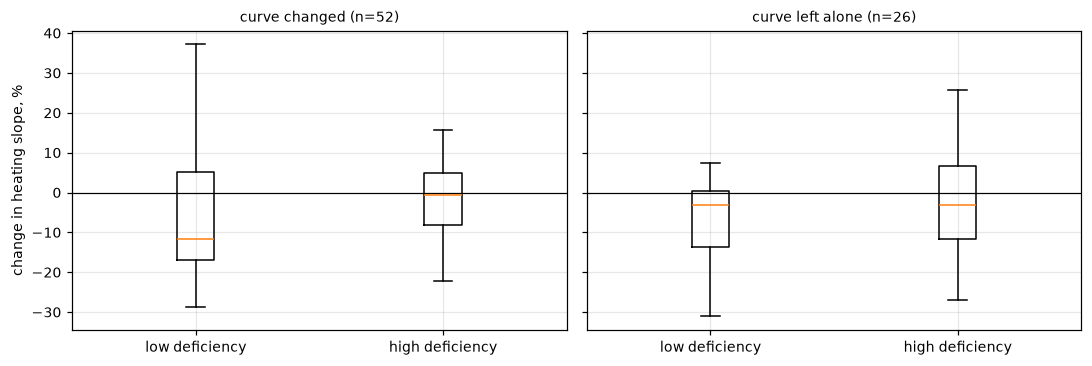

In [6]:
P7 = load("p7/data/p7_compensation.parquet")
if P7 is not None:
    ch = P7[P7.label_curve_changed == True].copy()
    un = P7[P7.label_curve_changed == False].copy()
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
    for a, df, title in [(ax[0], ch, "curve changed (n=%d)" % len(ch)),
                         (ax[1], un, "curve left alone (n=%d)" % len(un))]:
        if len(df) >= 8:
            df["g"] = pd.qcut(df.deficiency, 2, labels=["low deficiency", "high deficiency"])
            a.boxplot([df[df.g == k].d_slope_pct.dropna()
                       for k in ["low deficiency", "high deficiency"]],
                      tick_labels=["low deficiency", "high deficiency"], showfliers=False)
        a.axhline(0, color="k", lw=.8)
        a.set_title(title, fontsize=9)
    ax[0].set_ylabel("change in heating slope, %")
    plt.tight_layout(); plt.savefig(FIG / "D05_compensation.png", dpi=130)

## P8 — what does oversizing cost? *(a scenario)*

Nothing maps sizing ratio to an efficiency penalty, so this is a stated assumption:
no penalty at ratio 1.0, rising to a 5–15% seasonal penalty at ratio 2.0.

**Small across the fleet, concentrated in a minority.** It adds 2.6% to the total,
and the median house carries zero — but for some houses it exceeds their envelope
term. **It is shown separately and never added to the headline.**

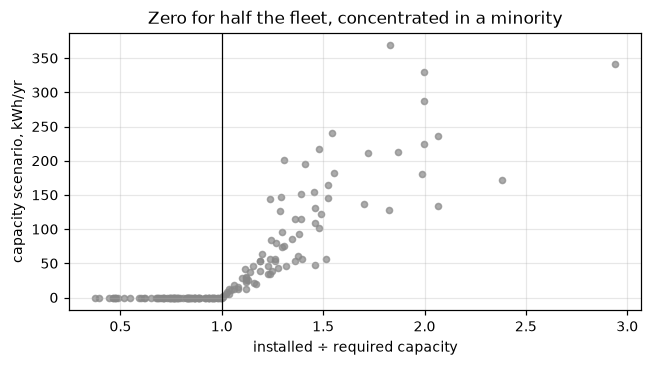

In [7]:
C = load("p8/data/p8_capacity_scenario.parquet")
if C is not None:
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.scatter(C.ratio, C.cap_MID, s=16, alpha=.7, color="#888888")
    ax.axvline(1.0, color="k", lw=.8)
    ax.set_xlabel("installed ÷ required capacity")
    ax.set_ylabel("capacity scenario, kWh/yr")
    ax.set_title("Zero for half the fleet, concentrated in a minority")
    plt.tight_layout(); plt.savefig(FIG / "D02_capacity.png", dpi=130)

## P9 — does the envelope term match the meter?

The envelope term carries about 80% of the deficiency, so it had to be checked
against something independent. The meter's heating slope is that check.

**Done per m²**, because both quantities grow with house size — a raw correlation
would mostly measure "big houses use more heat".

**Spearman +0.536 [0.422, 0.645] per m².** The physics ranks houses the way the
meter does. One qualification: it matches pre-1975 houses almost exactly and
under-predicts newer ones by 24–53%, so **houses are compared within their own
construction era.**

Spearman per m2: 0.536


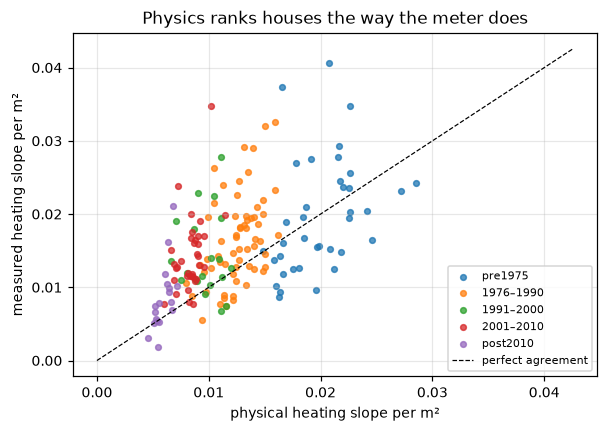

In [8]:
V = load("p9/data/p9_envelope_validation.parquet")
if V is not None:
    fig, ax = plt.subplots(figsize=(5.6, 4))
    for e in ERA:
        s = V[V.era == e]
        ax.scatter(s.beta_phys_m2, s.beta_meas_m2, s=14, alpha=.75,
                   label=e.replace("_", "–"))
    lim = [0, max(V.beta_phys_m2.max(), V.beta_meas_m2.max()) * 1.05]
    ax.plot(lim, lim, "k--", lw=.8, label="perfect agreement")
    ax.set_xlabel("physical heating slope per m²")
    ax.set_ylabel("measured heating slope per m²")
    ax.set_title("Physics ranks houses the way the meter does")
    ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(FIG / "D06_envelope_check.png", dpi=130)
    print("Spearman per m2: %.3f" % V[["beta_phys_m2", "beta_meas_m2"]]
          .corr(method="spearman").iloc[0, 1])

## P10 — does the method travel?

The physics layer knows nothing about HEAPO: it takes variable *roles*, and one
adapter maps each dataset onto them. Three adapters were run with the physics
unchanged. The third, on `meta_data.csv`, **correctly refuses**. It lacks the
construction era and per-storey geometry the physics needs, and says so before
computing anything.

In [9]:
mc = load("p10/data/p10_meta_contract.csv")
if mc is not None:
    display(mc[["role", "n_present", "status", "why_missing"]])

,role,n_present,status,why_missing
0,area_m2,1339,OK,NaN
1,footprint_m2,0,MISSING,no per-storey areas - only one whole-dwelling ...
2,n_storeys_above,0,MISSING,no storey information of any kind
3,heated_basement,0,MISSING,no basement information of any kind
4,era,0,MISSING,no construction or installation year exists in...
5,renovation_count,0,MISSING,no renovation flags
6,residents,1348,OK,NaN
7,hp_type,1354,OK,NaN
8,emitter,1310,OK,NaN
9,dhw_electric,1358,OK,NaN


## P11 — the building score

Four states, and none of them says *normal*. A normal state would require a house's
whole band to sit at or below code, and no house's does. So the model can confirm an
excess but never its absence.

| state | meaning |
|---|---|
| `HIGH_EXCESS` | confirmed excess over code, worst 25% of its era |
| `EXCESS_CONFIRMED` | confirmed excess, below that cut |
| `INCONCLUSIVE` | computed, but the band straddles zero |
| `INCOMPLETE_AUDIT` | not computed — building data missing, can be collected |

**Ranked on the lower bound**, the honest *at least this much*.

,households
phys_status,
EXCESS_CONFIRMED,114
INCOMPLETE_AUDIT,42
HIGH_EXCESS,41
INCONCLUSIVE,17


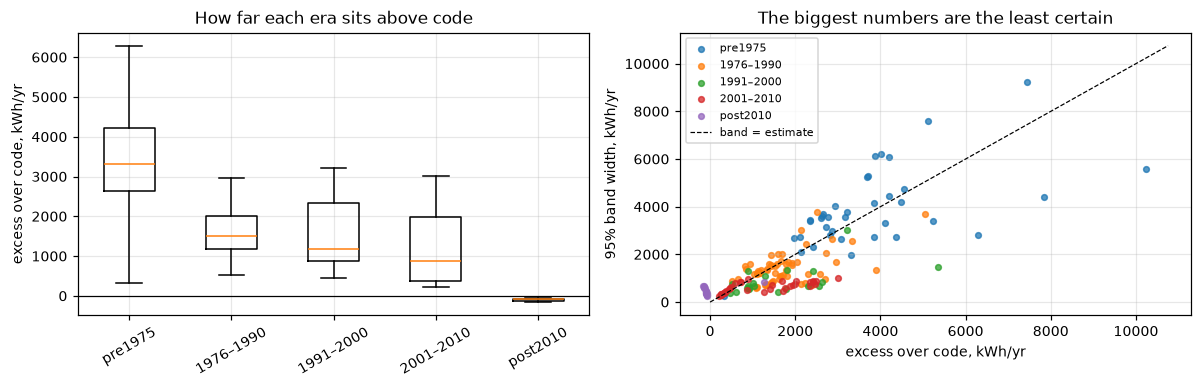

In [10]:
if E is not None:
    display(E.phys_status.value_counts().rename("households").to_frame())
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    s = E.dropna(subset=["phys_deficiency_kwh_yr"])
    d = [s[s.phys_era == e].phys_deficiency_kwh_yr for e in ERA]
    ax[0].boxplot(d, tick_labels=[e.replace("_", "–") for e in ERA], showfliers=False)
    ax[0].axhline(0, color="k", lw=.8)
    ax[0].set_ylabel("excess over code, kWh/yr")
    ax[0].set_title("How far each era sits above code")
    ax[0].tick_params(axis="x", rotation=30)
    for e in ERA:
        q = s[s.phys_era == e]
        ax[1].scatter(q.phys_deficiency_kwh_yr, q.phys_deficiency_band_kwh_yr,
                      s=14, alpha=.75, label=e.replace("_", "–"))
    lim = [0, s.phys_deficiency_kwh_yr.max() * 1.05]
    ax[1].plot(lim, lim, "k--", lw=.8, label="band = estimate")
    ax[1].set_xlabel("excess over code, kWh/yr")
    ax[1].set_ylabel("95% band width, kWh/yr")
    ax[1].set_title("The biggest numbers are the least certain")
    ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.savefig(FIG / "D01_by_era.png", dpi=130)

## P12 – P13 — the visit queue

**Ranked by the heating the building does not justify.** The measured heating slope
is compared with the physical one; the gap, over a year's weather, is the ranking
figure. Appliances drop out of this comparison because they don't depend on the
weather.

**Aaditya's fault model is added alongside as a percentage** — the probability it
gives for *heating curve too high* or *heating limit too high*. It is shown next to
each house for the technician and does not set the order.

**Two energy figures, never added together:** what a technician could reach by
changing a setting, and what only a builder can fix.

| state | meaning |
|---|---|
| `SLOPE_EXCESS` | heating the building does not justify — ranked within its era |
| `NO_SLOPE_EXCESS` | heating response fits the building |
| `NOT_ASSESSABLE` | not computed |

,house,era,"technician could reach, kWh/yr","builder only, kWh/yr","fault model, %",fault named
0,1114677,post2010,6162.0,1261.0,NaN,—
1,6981151,pre1975,5660.0,2722.0,98.0,heating limit too high
2,680861,1991_2000,5504.0,1007.0,83.0,heating curve too high
3,881223,1976_1990,5435.0,3340.0,20.0,—
4,991118,1976_1990,5004.0,2581.0,22.0,—
5,102766,2001_2010,4493.0,1678.0,NaN,—
6,816910,1991_2000,3896.0,2622.0,4.0,—
7,7374981,post2010,3752.0,-140.0,51.0,heating curve too high
8,105807,1976_1990,3516.0,1590.0,NaN,—
9,801031,2001_2010,3490.0,317.0,44.0,—


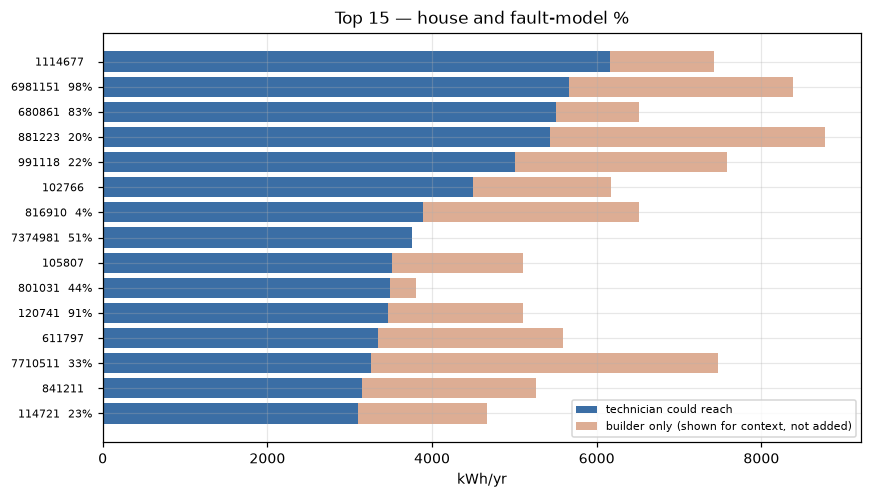

In [11]:
Q = load("p13/data/p13_visit_queue.parquet")
if Q is not None:
    se = Q[Q.visit_status == "SLOPE_EXCESS"].nlargest(15, "technician_recoverable_envelope_kwh")
    show = pd.DataFrame({
        "house": se.Household_ID.values,
        "era": se.era.values,
        "technician could reach, kWh/yr": se.technician_recoverable_envelope_kwh.values,
        "builder only, kWh/yr": se.not_recoverable_by_visit_kwh.values,
        "fault model, %": (se.max_filter_prob * 100).round(0).values,
        "fault named": se.named_fault.fillna("—").values})
    display(show)
    fig, ax = plt.subplots(figsize=(8, 4.6))
    y = np.arange(len(se))[::-1]
    ax.barh(y, se.technician_recoverable_envelope_kwh, color="#3b6ea5",
            label="technician could reach")
    ax.barh(y, se.not_recoverable_by_visit_kwh.clip(lower=0),
            left=se.technician_recoverable_envelope_kwh, color="#c26a3d", alpha=.55,
            label="builder only (shown for context, not added)")
    labels = ["%d  %s" % (h, ("%.0f%%" % (p * 100)) if pd.notna(p) else "")
              for h, p in zip(se.Household_ID, se.max_filter_prob)]
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel("kWh/yr"); ax.set_title("Top 15 — house and fault-model %")
    ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(FIG / "D03_visit_queue.png", dpi=130)

## Limitations of this model

| | |
|---|---|
| **Levels are not predictions** | `E_as_built` excludes appliance electricity. Only differences ship. |
| **Design-load offset** | The physics runs 1.13–1.49× the SIA 384.201 table. Unexplained, not tuned away. |
| **Era gradient too steep** | Newer houses under-predicted by 24–53% — compare within era. |
| **~22% slope baseline** | Every house shows some slope excess; ranking is within era. |
| **Short records** | Under 365 meter days, the weather correction is extrapolated. |
| **Swiss constants** | The code ports to other datasets; the constants do not. |
| **Constants second-hand** | Page citations exist; the standards themselves were not read here. |